<h1 align="center">Exercise 4</h1>
<h2 align="center">Intelligent Data Analysis</h2>
<h2 align="center">DV1597</h2>
<h3 align="center">Grace Dona Harlita Tarihoran (grta26@student.bth.se)</h3>

**Topic     : Image Data Analysis** </br>

**Sub Topic : Face Recognition**  </br>

**Task      : Face recognition using Euclidean Distance Metric**

# Introduction

The purpose of this exercise is to recognize five test face images using simple image statistics. Each image is represented by two values: the mean and the standard deviation. The test images are compared with five known persons: Andreas, Marie, Mikael, Stefan, and Ulf.

# Method

## Convert each image to grayscale
   Although the images visually appear to be grayscale, each image was converted to grayscale in Python to ensure that all images were represented using a single intensity channel before calculating the mean and standard deviation.

In [76]:
# Import the libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# Set the folder locations
people_dir = Path("People")
test_dir = Path("Test")

# List of persons in the People folder
persons = ["Andreas", "Marie", "Mikael", "Stefan", "Ulf"]

# Function to open an image and convert it to grayscale
def convert_to_grayscale(image_path):
    image = Image.open(image_path).convert("L")
    return image

## Calculate the statistical mean and standard deviation
Calculate the statistical mean and standard deviation of all images in each of the 5 folders (Andreas, Marie, Mikael, Stefan, Ulf).

In [77]:
# Function to calculate mean and standard deviation
def calculate_mean_std(image):
    array = np.asarray(image, dtype=np.float64)

    mean_value = array.mean()
    std_value = array.std()

    return mean_value, std_value

# Create an empty list to store the result for all training images
people_data = []

# Loop through each person folder
for person in persons:
    
    # Example: People/Andreas
    folder = people_dir / person

    # Loop through all PNG images in the person's folder
    for image_path in sorted(folder.glob("*.png")):
        
        # Step 1: Convert image to grayscale
        gray_image = convert_to_grayscale(image_path)

        # Step 2: Calculate mean and standard deviation
        mean_value, std_value = calculate_mean_std(gray_image)

        # Step 3: Store the result
        people_data.append({
            "Person": person,
            "Image": image_path.name,
            "Mean": mean_value,
            "Std": std_value
        })

# Convert the list into a pandas DataFrame
people_df = pd.DataFrame(people_data)

print("\nMean and standard deviation for all training images have been calculated.")


Mean and standard deviation for all training images have been calculated.


## Calculate the average mean and average standard deviation
Calculate the average mean and average standard deviation from the nine training images for each person

In [78]:
# Calculate the average mean and average standard deviation for each person
person_summary = people_df.groupby("Person")[["Mean", "Std"]].mean()

# Display the average mean and standard deviation for each person in a table 
print("\nAverage mean and standard deviation for each person:\n")
display(person_summary.round(4))


Average mean and standard deviation for each person:



,Mean,Std
Person,,
Andreas,103.9146,43.4088
Marie,170.1453,69.7032
Mikael,106.6726,45.9677
Stefan,174.5176,50.2704
Ulf,163.0294,58.2969


## Calculate the statistical mean and standard deviation for each test image

In [79]:
test_data = []

# For each file in Test folder, take the filename without .png
# Convert it into an integer, and use that number for sorting
# lambda is used to create a small temporary function
for image_path in sorted(test_dir.glob("*.png"), key=lambda x: int(x.stem)):
    # Step 1: Convert image to grayscale
    gray_image = convert_to_grayscale(image_path)

    # Step 2: Calculate mean and standard deviation
    mean_value, std_value = calculate_mean_std(gray_image)

    # Step 3: Store the result
    test_data.append({
        "Test Image": image_path.name,
        "Mean": mean_value,
        "Std": std_value
    })

# Convert the list into a pandas DataFrame
test_df = pd.DataFrame(test_data)
 
# Display the table
print("\nMean and standard deviation for test images:\n")
display(test_df.round(4))


Mean and standard deviation for test images:



,Test Image,Mean,Std
0,1.png,97.8205,41.4410
1,2.png,153.8360,73.9574
2,3.png,104.1319,45.9792
3,4.png,169.9220,48.4413
4,5.png,165.4917,57.0052


# Scatter Plot

The scatter plot shows the mean intensity value and standard deviation of all nine images for each person.

- Each point represents one image, and each color represents a different person.
- Images belonging to the same person tend to be grouped close together, forming a cluster.
- This makes it easier to visually compare the distribution of the images for the different persons.

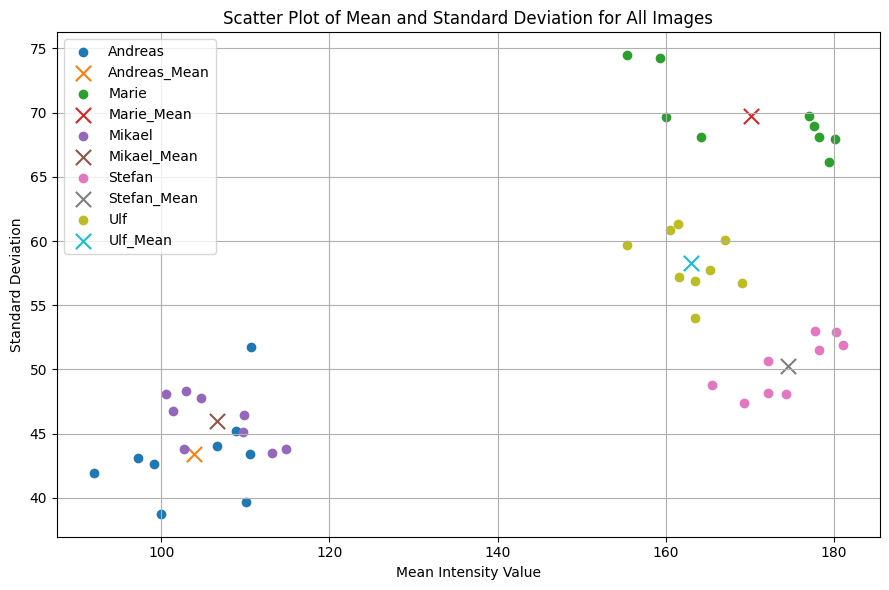

In [80]:
# Create a new figure for the scatter plot
plt.figure(figsize=(9, 6))

# Loop through each person: Andreas, Marie, Mikael, Stefan, and Ulf
for person in persons:

    # Select only the rows/images that belong to the current person
    group = people_df[people_df["Person"] == person]

    # Plot the 9 images of the current person
    plt.scatter(
        group["Mean"], # x-axis = Mean
        group["Std"],  # y-axis = Standard deviation
        label=person   # label is used for the legend
    )

    # Plot the average point of the current person
    plt.scatter(
        person_summary.loc[person, "Mean"],
        person_summary.loc[person, "Std"],
        marker="x",
        s=120,
        label=f"{person}_Mean"
    )

# Add label for the x-axis
plt.xlabel("Mean Intensity Value")

# Add label for the y-axis
plt.ylabel("Standard Deviation")

# Add title for the plot
plt.title("Scatter Plot of Mean and Standard Deviation for All Images")

# Show the legend so we know which points belong to which person
plt.legend()

# Add grid lines to make the plot easier to read
plt.grid(True)

# Adjust spacing so labels and title are not cut off
plt.tight_layout()

# Display the plot in the notebook
plt.show()

# Distance Table

Each test image was compared with every person using the **Euclidean distance metric**.

- The comparison was based on two image features: the mean intensity value and the standard deviation.
- For each test image, these two values were compared with the average mean intensity value and average standard deviation of each person.
- The person with the smallest Euclidean distance was selected as the predicted label.

In [81]:
# Create an empty list to store the distance results
distance_data = []

# Go through each row in the test image table
for _, test_row in test_df.iterrows():

    # Create a new row for the distance table
    # Start by storing the test image name
    row = {"Test Image": test_row["Test Image"]}

    # Get the mean and standard deviation of the current test image
    test_mean = test_row["Mean"]
    test_std = test_row["Std"]

    # Compare the current test image with each person
    for person in person_summary.index:

        # Get the average mean and average standard deviation of this person
        person_mean = person_summary.loc[person, "Mean"]
        person_std = person_summary.loc[person, "Std"]

        # Calculate the Euclidean distance between the test image point and the person
        distance = np.sqrt(
            (test_mean - person_mean) ** 2 +
            (test_std - person_std) ** 2
        )

        # Store the calculated distance in the row
        row[person] = distance

    # Create a dictionary containing only the distance values
    distances = {person: row[person] for person in persons}

    # Find the person with the smallest distance
    row["True Label"] = min(distances, key=distances.get)

    # Add the completed row to the distance_data list
    distance_data.append(row)

# Convert the distance_data list into a pandas DataFrame
distance_df = pd.DataFrame(distance_data)

# Print the distance table in the output
print("\nDistance table:\n")
print(distance_df.round(4))


Distance table:

  Test Image  Andreas    Marie   Mikael   Stefan      Ulf True Label
0      1.png   6.4039  77.6507   9.9424  77.2036  67.3523    Andreas
1      2.png  58.5266  16.8550  54.8435  31.4453  18.1596      Marie
2      3.png   2.5796  70.1469   2.5407  70.5163  60.1718     Mikael
3      4.png  66.1989  21.2630  63.2977   4.9462  12.0266     Stefan
4      5.png  63.0603  13.5238  59.8458  11.2616   2.7805        Ulf


The final predictions based on the smallest Euclidean distance are: </br>

1.png → Andreas (6.4039) </br>

2.png → Marie (16.8550)</br>

3.png → Mikael (2.5407)</br>

4.png → Stefan (4.9462)</br>

5.png → Ulf (2.7805)

# Discussion

- The scatter plot shows that the images from the same person tend to be located close to each other. This means that the nine images of each person have similar mean intensity values and standard deviation values. Therefore, the points form small clusters for each person.
   
- From the scatter plot, Andreas and Mikael appear close to each other because their mean and standard deviation values are similar. This makes them more difficult to separate compared with the other persons. Marie, Stefan, and Ulf have higher mean intensity values, so they are located in a different area of the plot.

- It was easier to spot general patterns in the scatter plot than in the table because the plot gives a visual overview of the clusters.

- In the plot, it is easier to see which persons are close to each other and which persons are clearly separated. However, the distance table is more precise because it shows the exact Euclidean distance values. 



# Conclusion

- The Euclidean distance method was used to classify the five test face images. Each image was represented by two statistical features: the mean intensity value and the standard deviation. The mean and standard deviation of each test image were compared with the average mean and average standard deviation of each person.

- The result shows that each test image was classified based on the smallest Euclidean distance. Test image 1 was classified as Andreas, test image 2 as Marie, test image 3 as Mikael, test image 4 as Stefan, and test image 5 as Ulf.

- The method successfully recognized all five test images.

**The scatter plot is useful for observing patterns, while the distance table is better for making the final prediction by providing the exact numerical values.**